In [1]:
import pandas as pd
from training_logs_analysis import parse_client_csv, process_fp_logs


In [30]:
path = "/home/brian_bosho/FP/FP/federated-gnn/src/results/simple_test/Cora_adjacency_GCN/training_Cora_adjacency_GCN_20250504_032218.csv"

In [31]:
dfs = parse_client_csv(path)

In [32]:
dfs.keys()


dict_keys(['loss_df', 'acc_df', 'loss_df_step', 'acc_df_step', 'avg_loss_df', 'avg_acc_df', 'epoch_loss_df', 'epoch_acc_df', 'final_loss_df', 'final_acc_df'])

In [33]:
final_loss_df = dfs['final_loss_df']
final_loss_df


client_id,0,1,2,3,4,5,6,7,8,9
round,,,,,,,,,,
0,1.617983,1.666507,1.505600,1.663164,1.536658,1.673090,1.587124,1.701395,1.690206,1.745047
1,1.499519,1.550107,1.309757,1.302135,1.435691,1.559167,1.492157,1.567578,1.585623,1.616712
2,1.448264,1.494196,1.280331,1.176960,1.273049,1.457394,1.269521,1.389864,1.513383,1.573967
3,1.157523,1.158076,1.095580,0.985330,1.187552,1.250775,1.211601,1.293677,1.247550,1.345529
4,0.988273,1.135282,0.974923,1.062103,1.064115,1.098737,0.952076,1.097515,1.267285,1.215188
...,...,...,...,...,...,...,...,...,...,...
95,0.028177,0.074243,0.047152,0.090827,0.033305,0.114440,0.109540,0.062078,0.060744,0.091165
96,0.073115,0.054428,0.071388,0.047696,0.053200,0.035909,0.048006,0.074362,0.051137,0.078242
97,0.019462,0.113164,0.024598,0.041577,0.037321,0.124507,0.209486,0.059547,0.028682,0.145646


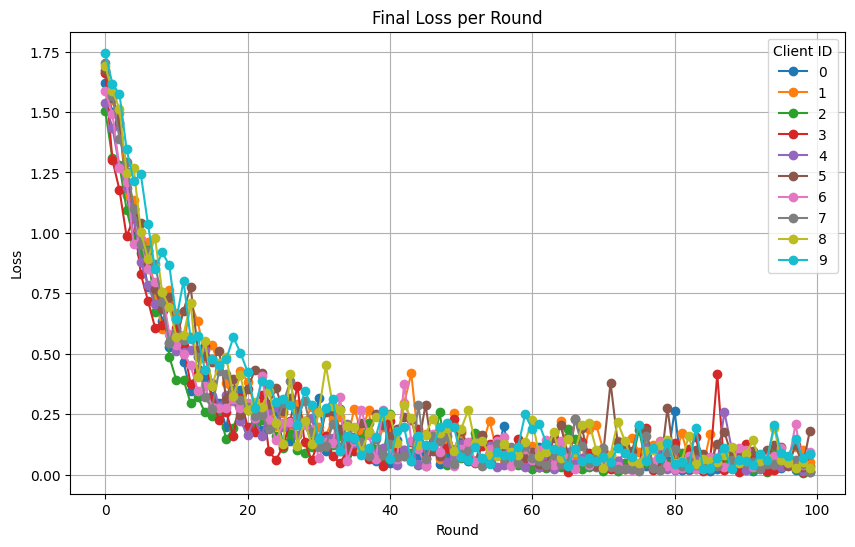

In [34]:
# plot final loss
import matplotlib.pyplot as plt
final_loss_df.plot(figsize=(10, 6), marker='o')
plt.title("Final Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(title="Client ID")

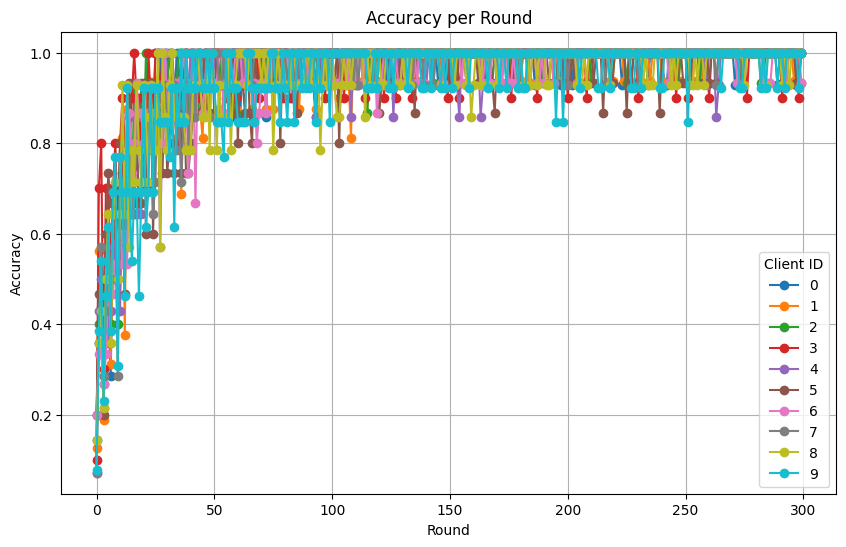

In [35]:
acc_df_step = dfs['acc_df_step']
# plot
acc_df_step.plot(figsize=(10, 6), marker='o')
plt.title("Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(title="Client ID")


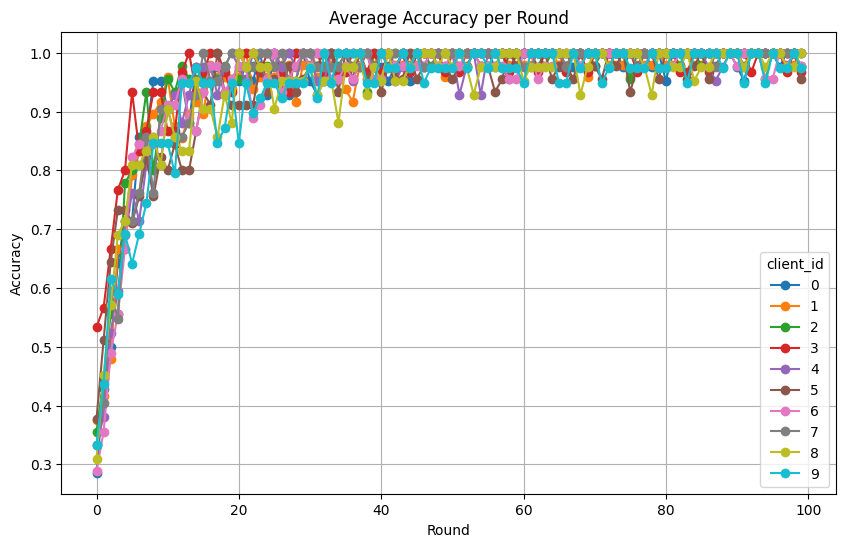

In [36]:
avg_acc_df = dfs['avg_acc_df']
# plot
avg_acc_df.plot(figsize=(10, 6), marker='o')
plt.title("Average Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)

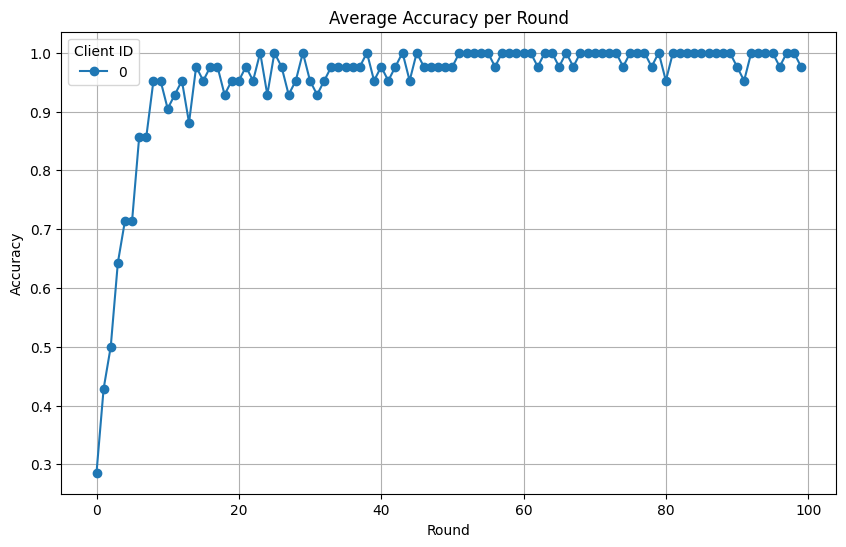

In [39]:
avg_acc_df[0].plot(figsize=(10, 6), marker='o')
plt.title("Average Accuracy per Round")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(title="Client ID")


### lets review the results folder results

In [7]:
from process_results import process_results_folder_json

In [8]:
test_results = "/home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients"

In [9]:
df = process_results_folder_json(test_results)
df

INFO: Scanning folder: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_adjacency_GCN/results_Cora_adjacency_GCN_20250503_211641.json
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_full_GCN/results_Cora_full_GCN_20250503_211618.json
INFO: Successfully created DataFrame with 2 rows.


,device,data_loading_option,model_type,dataset,num_clients,beta,hop,fulltraining_flag,global_results,client_results,average_global_result,average_client_result,std_global,std_client,experiment_id
0,cuda,adjacency,GCN,Cora,5,1,1,False,[0.656],[0.6805602731152979],0.656,0.680560,0.0,0.0,results_Cora_adjacency_GCN_20250503_211641
1,cuda,full,GCN,Cora,5,1,1,False,[0.7],[0.7063045451617194],0.700,0.706305,0.0,0.0,results_Cora_full_GCN_20250503_211618


### FP logs

In [10]:
iid_json = "/home/brian_bosho/FP/FP/federated-gnn/logs/propagation_stats/prop_exp_20250504-053125_adjacency_beta_10000_hop_1.json"
stats = process_fp_logs(iid_json)

stats.keys()


dict_keys(['fp_stats_df', 'deltas_df', 'energy_raw_df', 'energy_per_node_df', 'energy_per_edge_df'])

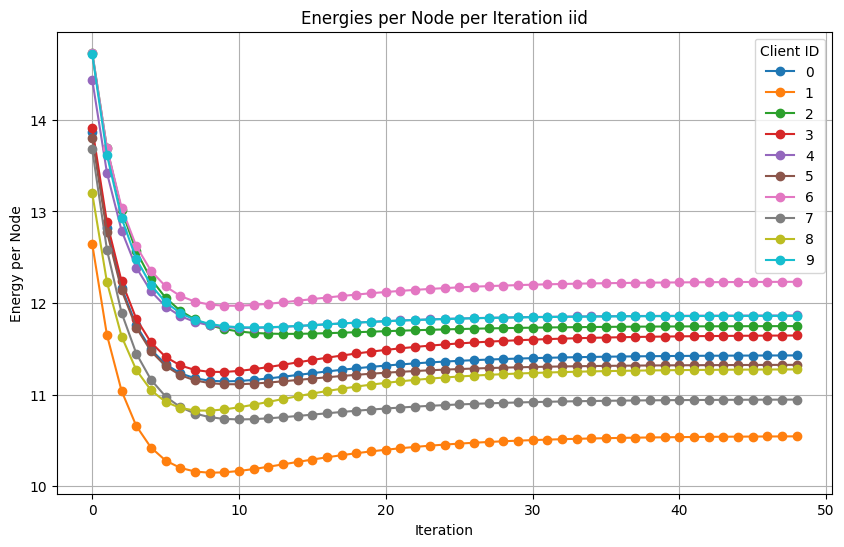

In [11]:
iid_energy_per_node_df = stats["energy_per_node_df"]
iid_energy_per_node_df

# plot
import matplotlib.pyplot as plt
iid_energy_per_node_df.plot(figsize=(10, 6), marker='o')
plt.title("Energies per Node per Iteration iid")
plt.xlabel("Iteration")
plt.ylabel("Energy per Node")
plt.grid(True)
plt.legend(title="Client ID")

In [12]:
non_iid_json = "/home/brian_bosho/FP/FP/federated-gnn/logs/propagation_stats/prop_exp_20250504-024847_adjacency_beta_0.5_hop_1.json"
non_iid_stats = process_fp_logs(non_iid_json)
non_iid_stats.keys()



dict_keys(['fp_stats_df', 'deltas_df', 'energy_raw_df', 'energy_per_node_df', 'energy_per_edge_df'])

Text(0.5, 0, 'Iteration')

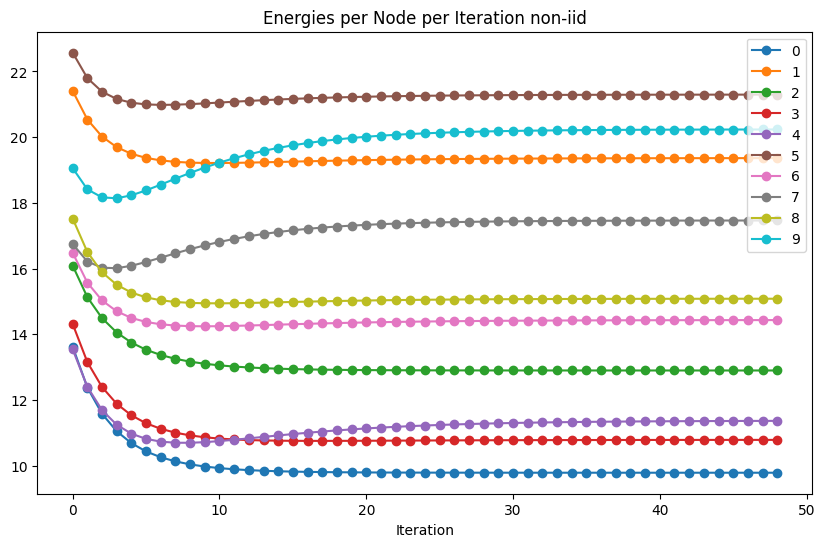

In [13]:
non_iid_energy_per_node_df = non_iid_stats["energy_per_node_df"]
non_iid_energy_per_node_df

# plot
non_iid_energy_per_node_df.plot(figsize=(10, 6), marker='o')
plt.title("Energies per Node per Iteration non-iid")
plt.xlabel("Iteration")

### PE Logs

In [15]:
pe_json = "/home/brian_bosho/FP/FP/federated-gnn/logs/propagation_stats/prop_exp_20250504-060104_adjacency_beta_10000_hop_1.json"
pe_stats = process_fp_logs(pe_json)
pe_stats.keys()

pe_energy_per_node_df = pe_stats["energy_per_node_df"]
pe_energy_per_node_df


,0,1,2,3,4,5,6,7,8,9
iteration,,,,,,,,,,
0,0.942378,0.916723,1.000768,0.916188,0.962401,0.960302,0.979439,0.921638,0.963887,0.988969
1,0.871615,0.845848,0.929581,0.845552,0.893785,0.888832,0.911522,0.846902,0.895286,0.915785
2,0.827805,0.802200,0.883329,0.801301,0.851025,0.844310,0.868862,0.799799,0.852782,0.870062
3,0.800325,0.775122,0.852477,0.773197,0.823817,0.816179,0.841619,0.769526,0.826305,0.840902
4,0.783148,0.758531,0.831582,0.755390,0.806384,0.798419,0.824201,0.749956,0.810006,0.822173
5,0.772621,0.748722,0.817316,0.744307,0.795254,0.787363,0.813196,0.737367,0.800287,0.810180
6,0.766442,0.743345,0.807554,0.737677,0.788251,0.780689,0.806434,0.729404,0.794858,0.802608
7,0.763118,0.740870,0.800893,0.734013,0.783975,0.776893,0.802497,0.724533,0.792225,0.797961
8,0.761664,0.740284,0.796391,0.732325,0.781504,0.774984,0.800442,0.721737,0.791406,0.795255


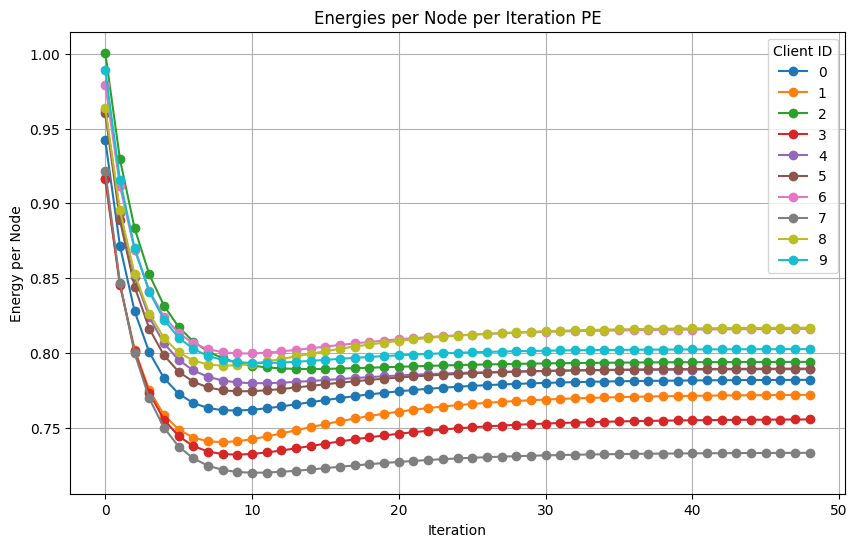

In [16]:
# plot
pe_energy_per_node_df.plot(figsize=(10, 6), marker='o')
plt.title("Energies per Node per Iteration PE")
plt.xlabel("Iteration")
plt.ylabel("Energy per Node")
plt.grid(True)
plt.legend(title="Client ID")